In [27]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import re
from collections import Counter

df = pd.read_csv('Airline_review.csv')[['Review', 'Recommended']].dropna()
df['Recommended'] = df['Recommended'].map({'yes': 1, 'no': 0})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['Review_Clean'] = df['Review'].apply(clean_text)
X_raw = df['Review_Clean'].values
y = df['Recommended'].values

test_samples = [
    "Amazing flight, the staff was so kind and the food was delicious!", 
    "Terrible experience. Delayed for 5 hours and lost my luggage.",      
    "The flight was okay, but the seats were a bit cramped.",             
    "Great service? No, it was a disaster from start to finish."         
]

results_acc = {}
final_test_results = {sample: [] for sample in test_samples}

In [28]:
def train_bow_model(X_data, y_data, name):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

    model = nn.Sequential(
        nn.Linear(X_data.shape[1], 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 1),
        nn.Sigmoid()
    )
    
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()
    
    X_tr = torch.FloatTensor(X_train.toarray())
    y_tr = torch.FloatTensor(y_train)
    
    for epoch in range(20):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr).squeeze(), y_tr)
        loss.backward()
        optimizer.step()
    
    # Оценка
    model.eval()
    with torch.no_grad():
        preds = (model(torch.FloatTensor(X_test.toarray())).squeeze() > 0.5).int()
        acc = accuracy_score(y_test, preds)
    return model, acc

In [29]:
print("Обучение Binary BoW...")
vec_bin = CountVectorizer(max_features=1000, binary=True)
model_bin, results_acc['Binary BoW'] = train_bow_model(vec_bin.fit_transform(X_raw), y, "Binary")

Обучение Binary BoW...


In [30]:
print("Обучение Frequency BoW...")
vec_freq = CountVectorizer(max_features=1000, binary=False)
model_freq, results_acc['Frequency'] = train_bow_model(vec_freq.fit_transform(X_raw), y, "Frequency")

Обучение Frequency BoW...


In [31]:
all_words = ' '.join(df['Review_Clean']).split()
word_counts = Counter(all_words)
vocab = {word: i+2 for i, (word, count) in enumerate(word_counts.most_common(1000))}
vocab['<PAD>'], vocab['<UNK>'] = 0, 1

def to_idx(text, max_len=100):
    indices = [vocab.get(w, 1) for w in text.split()]
    return indices[:max_len] + [0]*(max_len - len(indices[:max_len]))

X_emb = np.array([to_idx(t) for t in X_raw])
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_emb, y, test_size=0.2, random_state=42)

class EmbedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(1002, 32, padding_idx=0)
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(3200, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, x): return self.net(self.emb(x))

print("Обучение Dense Embeddings...")
model_emb = EmbedNet()
opt_e = optim.Adam(model_emb.parameters(), lr=0.001)
for e in range(20):
    model_emb.train(); opt_e.zero_grad()
    loss = nn.BCELoss()(model_emb(torch.LongTensor(X_train_e)).squeeze(), torch.FloatTensor(y_train_e))
    loss.backward(); opt_e.step()

Обучение Dense Embeddings...


In [32]:
with torch.no_grad():
    preds_e = (model_emb(torch.LongTensor(X_test_e)).squeeze() > 0.5).float()
    results_acc['Dense Embedding'] = accuracy_score(y_test_e, preds_e.numpy())

In [33]:
print("\n--- СРАВНИТЕЛЬНЫЕ ТЕСТЫ ---")
for s in test_samples:
    # Binary
    b_res = "YES" if model_bin(torch.FloatTensor(vec_bin.transform([clean_text(s)]).toarray())).item() > 0.5 else "NO"
    # Freq
    f_res = "YES" if model_freq(torch.FloatTensor(vec_freq.transform([clean_text(s)]).toarray())).item() > 0.5 else "NO"
    # Emb
    e_res = "YES" if model_emb(torch.LongTensor([to_idx(clean_text(s))])).item() > 0.5 else "NO"
    print(f"Review: {s[:30]}... | Bin: {b_res} | Freq: {f_res} | Emb: {e_res}")


--- СРАВНИТЕЛЬНЫЕ ТЕСТЫ ---
Review: Amazing flight, the staff was ... | Bin: YES | Freq: YES | Emb: YES
Review: Terrible experience. Delayed f... | Bin: NO | Freq: NO | Emb: NO
Review: The flight was okay, but the s... | Bin: YES | Freq: YES | Emb: NO
Review: Great service? No, it was a di... | Bin: NO | Freq: NO | Emb: YES


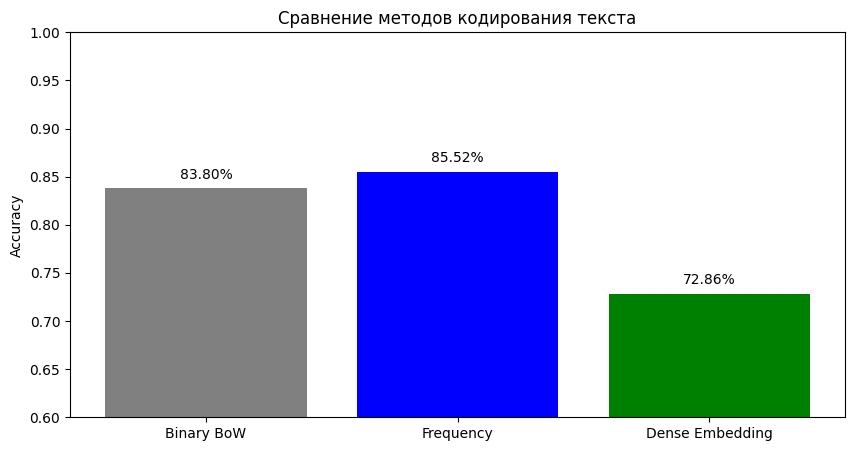

In [34]:
plt.figure(figsize=(10, 5))
plt.bar(results_acc.keys(), results_acc.values(), color=['gray', 'blue', 'green'])
plt.ylabel('Accuracy'); plt.title('Сравнение методов кодирования текста'); plt.ylim(0.6, 1)
for i, v in enumerate(results_acc.values()):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center')
plt.show()

In [2]:
import pandas as pd
df = pd.read_csv('Airline_review.csv')[['Review', 'Recommended']].dropna()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review       23171 non-null  object
 1   Recommended  23171 non-null  object
dtypes: object(2)
memory usage: 362.2+ KB
